# 🔮 Módulo 12: Redes Bayesianas e Naive Bayes

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

- ✅ Compreender e aplicar o **Teorema de Bayes** para atualização de crenças
- ✅ Implementar o **Naive Bayes Gaussiano** para features contínuas
- ✅ Utilizar **Naive Bayes Bernoulli** para features binárias
- ✅ Aplicar **Naive Bayes Multinomial** para classificação de texto
- ✅ Comparar as variantes de Naive Bayes e escolher a mais adequada para cada problema
- ✅ Entender as vantagens e limitações da suposição de independência condicional

---

## Estrutura do Módulo

1. Teoria e Equações Fundamentais
2. Teorema de Bayes — Exemplo Médico Intuitivo
3. Gaussian Naive Bayes — Dataset de Crédito
4. Multinomial NB para Texto + Comparação de Modelos
5. Resumo e Exercícios

---

> **Intuição:** O Naive Bayes pergunta: *"Dado o que eu já sei (prior), o que esta nova evidência me diz sobre a probabilidade de cada classe?"*

## 2. Teoria e Equações

### 2.1 Teorema de Bayes
$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)} = \frac{P(E|H) \cdot P(H)}{\sum_h P(E|h) \cdot P(h)}$$
- $P(H)$: probabilidade a priori (antes da evidência)
- $P(E|H)$: verossimilhança (probabilidade da evidência dado H)
- $P(H|E)$: probabilidade a posteriori (após a evidência)

### 2.2 Classificador Naive Bayes
Assume independência condicional entre features dado a classe:
$$P(C_k|\mathbf{x}) \propto P(C_k) \prod_{i=1}^n P(x_i|C_k)$$

**Log-Probabilidade (numericamente estável):**
$$\log P(C_k|\mathbf{x}) = \log P(C_k) + \sum_{i=1}^n \log P(x_i|C_k)$$

### 2.3 Variantes do Naive Bayes
| Variante | Distribuição P(xᵢ|Cₖ) | Uso típico |
|----------|----------------------|-----------|
| Gaussian NB | $\mathcal{N}(\mu_{ik}, \sigma_{ik}^2)$ | Features contínuas |
| Bernoulli NB | $p^{x_i}(1-p)^{1-x_i}$ | Features binárias (0/1) |
| Multinomial NB | $\text{Multinomial}$ | Contagem de palavras (texto) |
| Complement NB | Complemento de MNB | Classificação de texto desbalanceada |

### 2.4 Gaussian Naive Bayes
$$P(x_i|C_k) = \frac{1}{\sqrt{2\pi\sigma_{ik}^2}} \exp\left(-\frac{(x_i-\mu_{ik})^2}{2\sigma_{ik}^2}\right)$$

🏥 TEOREMA DE BAYES — DIAGNÓSTICO MÉDICO

Prevalência da doença: 1.0%
Sensibilidade do teste: 95.0%
Especificidade do teste: 90.0%

P(doença|teste positivo) = 8.756%

💡 Mesmo com teste 95% preciso, apenas 8.8% dos positivos têm a doença!
   (Devido à baixa prevalência de 1.0%)


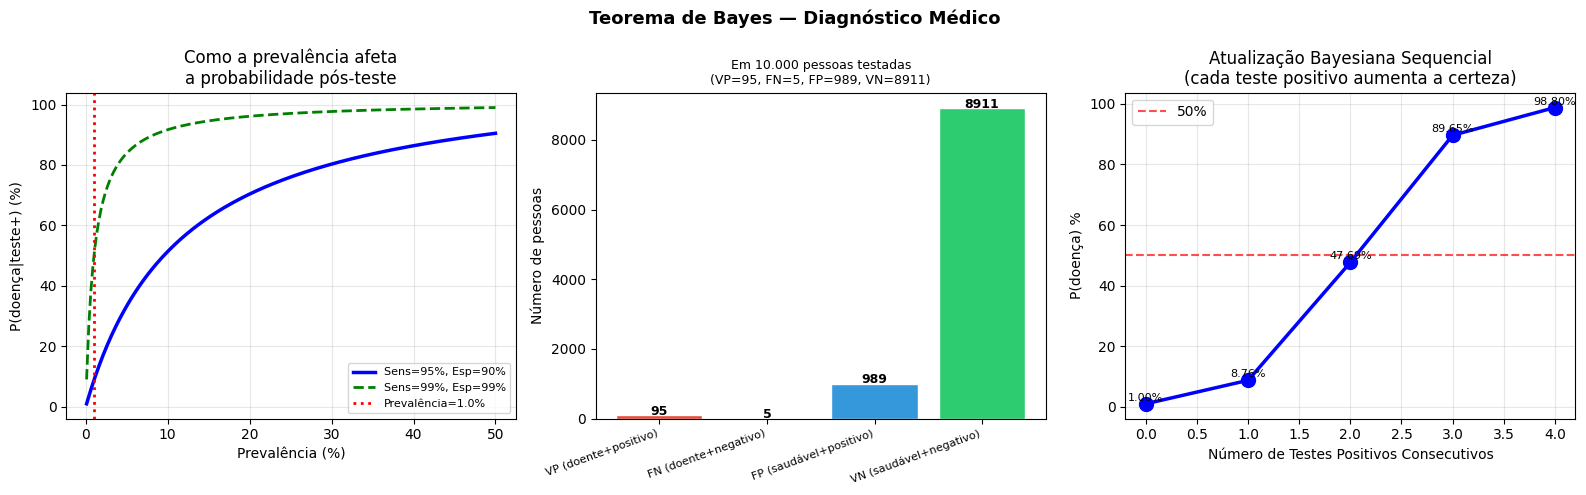

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ============================================================
# EXEMPLO INTUITIVO: Teorema de Bayes na Medicina
# ============================================================
print("=" * 55)
print("🏥 TEOREMA DE BAYES — DIAGNÓSTICO MÉDICO")
print("=" * 55)

# Parâmetros do problema
prevalencia = 0.01          # 1% da população tem a doença
sensibilidade = 0.95        # P(teste+|doença) = 95%
especificidade = 0.90       # P(teste-|saudável) = 90%

# Calcular probabilidade pós-teste
p_doenca = prevalencia
p_saudavel = 1 - prevalencia
p_teste_pos_doente = sensibilidade
p_teste_pos_saudavel = 1 - especificidade

# Bayes
p_doente_dado_pos = (p_teste_pos_doente * p_doenca) / \
                     (p_teste_pos_doente * p_doenca + p_teste_pos_saudavel * p_saudavel)

print(f"\nPrevalência da doença: {prevalencia:.1%}")
print(f"Sensibilidade do teste: {sensibilidade:.1%}")
print(f"Especificidade do teste: {especificidade:.1%}")
print(f"\nP(doença|teste positivo) = {p_doente_dado_pos:.3%}")
print(f"\n💡 Mesmo com teste 95% preciso, apenas {p_doente_dado_pos:.1%} dos positivos têm a doença!")
print(f"   (Devido à baixa prevalência de {prevalencia:.1%})")

# Visualização: como a probabilidade pós-teste varia com a prevalência
prevalencias = np.linspace(0.001, 0.5, 200)
p_pos = (sensibilidade * prevalencias) / \
        (sensibilidade * prevalencias + (1-especificidade) * (1-prevalencias))
p_pos_alta_sens = (0.99 * prevalencias) / \
                   (0.99 * prevalencias + (0.01) * (1-prevalencias))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Teorema de Bayes — Diagnóstico Médico', fontsize=13, fontweight='bold')

axes[0].plot(prevalencias*100, p_pos*100, 'b-', lw=2.5, label=f'Sens={sensibilidade:.0%}, Esp={especificidade:.0%}')
axes[0].plot(prevalencias*100, p_pos_alta_sens*100, 'g--', lw=2, label='Sens=99%, Esp=99%')
axes[0].axvline(prevalencia*100, color='red', lw=2, linestyle=':', label=f'Prevalência={prevalencia:.1%}')
axes[0].set_xlabel('Prevalência (%)'); axes[0].set_ylabel('P(doença|teste+) (%)')
axes[0].set_title('Como a prevalência afeta\na probabilidade pós-teste')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Representação visual de 10.000 pessoas
n_pop = 10000
n_doentes = int(n_pop * prevalencia)
n_saudaveis = n_pop - n_doentes
VP = int(n_doentes * sensibilidade)
FN = n_doentes - VP
FP = int(n_saudaveis * (1 - especificidade))
VN = n_saudaveis - FP

dados_pop = pd.DataFrame({'Categoria': ['VP (doente+positivo)', 'FN (doente+negativo)', 
                                          'FP (saudável+positivo)', 'VN (saudável+negativo)'],
                            'N': [VP, FN, FP, VN],
                            'Cor': ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']})
bars = axes[1].bar(dados_pop['Categoria'], dados_pop['N'], color=dados_pop['Cor'], edgecolor='white')
axes[1].set_title(f'Em 10.000 pessoas testadas\n(VP={VP}, FN={FN}, FP={FP}, VN={VN})', fontsize=9)
axes[1].set_ylabel('Número de pessoas')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right', fontsize=8)
for bar, n in zip(bars, dados_pop['N']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(n), 
                  ha='center', fontsize=9, fontweight='bold')

# Atualização sequencial de crenças (Bayes iterativo)
priori = [prevalencia]
for _ in range(4):
    p_anterior = priori[-1]
    p_novo = (sensibilidade * p_anterior) / \
              (sensibilidade * p_anterior + (1-especificidade) * (1-p_anterior))
    priori.append(p_novo)

axes[2].plot(range(5), [p*100 for p in priori], 'b-o', lw=2.5, ms=10)
axes[2].axhline(50, color='red', lw=1.5, linestyle='--', alpha=0.7, label='50%')
axes[2].set_xlabel('Número de Testes Positivos Consecutivos')
axes[2].set_ylabel('P(doença) %')
axes[2].set_title('Atualização Bayesiana Sequencial\n(cada teste positivo aumenta a certeza)')
for i, p in enumerate(priori):
    axes[2].text(i, p*100+1, f'{p:.2%}', ha='center', fontsize=8)
axes[2].grid(True, alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.savefig('../imagens/12_bayes_medico.png', dpi=150, bbox_inches='tight')
plt.show()

📊 GAUSSIAN NAIVE BAYES — CLASSIFICAÇÃO DE CRÉDITO
AUC-ROC: 0.8337
Acurácia: 0.8100


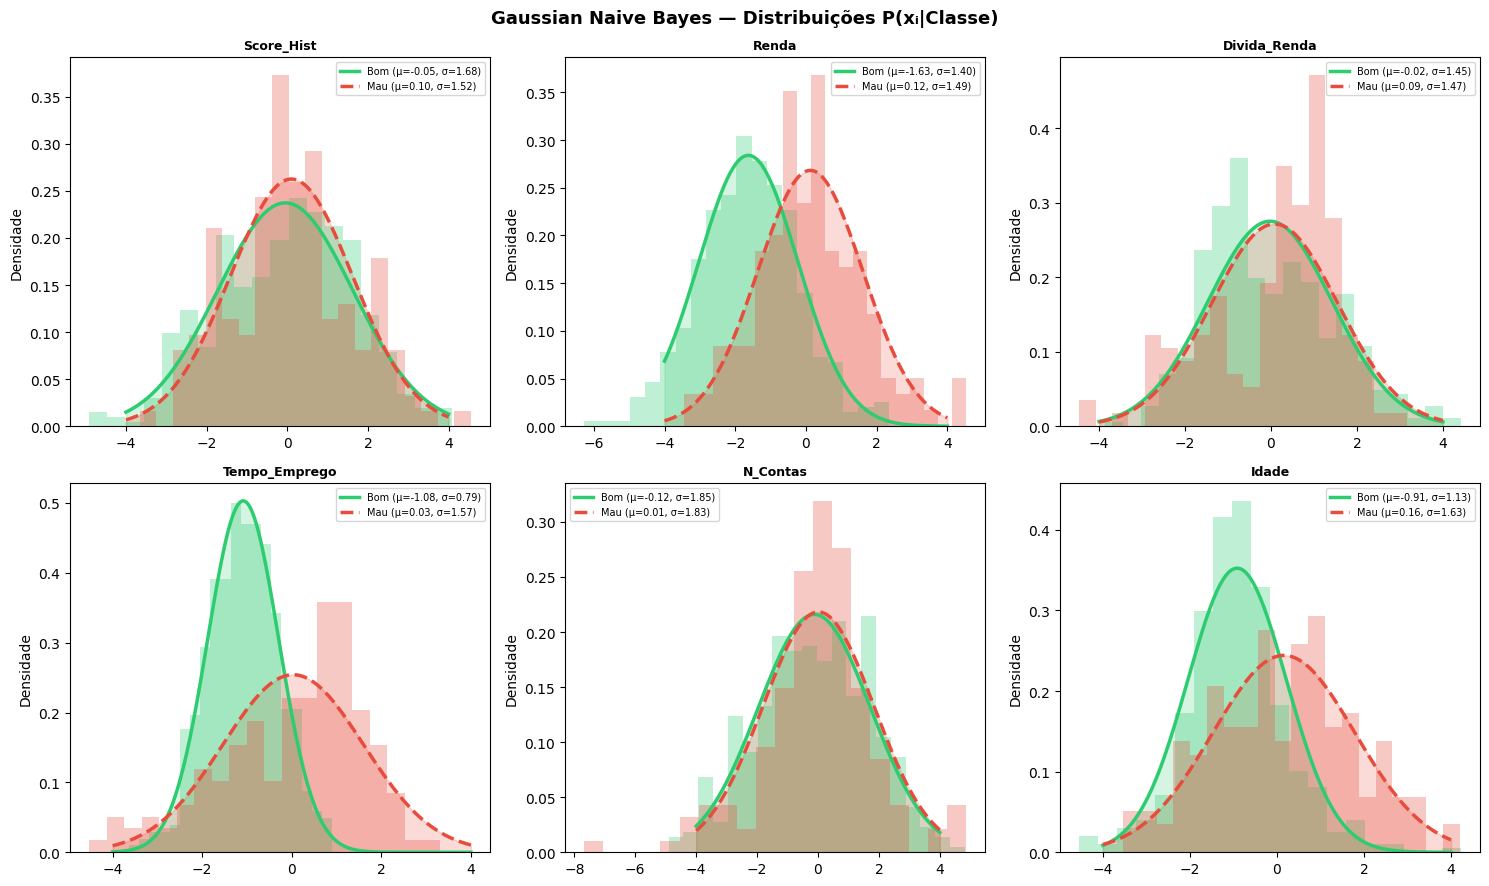

In [2]:
from sklearn.datasets import make_classification

print("=" * 55)
print("📊 GAUSSIAN NAIVE BAYES — CLASSIFICAÇÃO DE CRÉDITO")
print("=" * 55)

X_cred, y_cred = make_classification(n_samples=800, n_features=6, n_informative=4, 
                                       weights=[0.75, 0.25], random_state=42)
feat_names = ['Score_Hist', 'Renda', 'Divida_Renda', 'Tempo_Emprego', 'N_Contas', 'Idade']
X_tr, X_te, y_tr, y_te = train_test_split(X_cred, y_cred, test_size=0.25, stratify=y_cred, random_state=42)

# Treinar GNB
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
y_prob = gnb.predict_proba(X_te)[:,1]

print(f"AUC-ROC: {roc_auc_score(y_te, y_prob):.4f}")
print(f"Acurácia: {gnb.score(X_te, y_te):.4f}")

# Distribuições P(x|C) para cada feature
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Gaussian Naive Bayes — Distribuições P(xᵢ|Classe)', fontsize=13, fontweight='bold')

x_range_all = np.linspace(-4, 4, 200)
for ax, (feat_idx, feat_nome) in zip(axes.flatten(), enumerate(feat_names)):
    mu_bom = gnb.theta_[0, feat_idx]
    mu_mau = gnb.theta_[1, feat_idx]
    var_bom = gnb.var_[0, feat_idx]
    var_mau = gnb.var_[1, feat_idx]
    
    from scipy.stats import norm
    p_bom = norm.pdf(x_range_all, mu_bom, np.sqrt(var_bom))
    p_mau = norm.pdf(x_range_all, mu_mau, np.sqrt(var_mau))
    
    ax.plot(x_range_all, p_bom, '#2ecc71', lw=2.5, label=f'Bom (μ={mu_bom:.2f}, σ={np.sqrt(var_bom):.2f})')
    ax.plot(x_range_all, p_mau, '#e74c3c', lw=2.5, linestyle='--', label=f'Mau (μ={mu_mau:.2f}, σ={np.sqrt(var_mau):.2f})')
    ax.fill_between(x_range_all, p_bom, alpha=0.2, color='#2ecc71')
    ax.fill_between(x_range_all, p_mau, alpha=0.2, color='#e74c3c')
    ax.set_title(feat_nome, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7); ax.set_ylabel('Densidade')
    
    # Dados reais sobrepostos
    ax.hist(X_tr[y_tr==0, feat_idx], bins=20, density=True, alpha=0.3, color='#2ecc71')
    ax.hist(X_tr[y_tr==1, feat_idx], bins=20, density=True, alpha=0.3, color='#e74c3c')

plt.tight_layout()
plt.savefig('../imagens/12_gnb_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()

📧 MULTINOMIAL NAIVE BAYES — CLASSIFICAÇÃO DE TEXTO (SPAM)
Multinomial NB — Acurácia CV: 0.750 ± 0.274


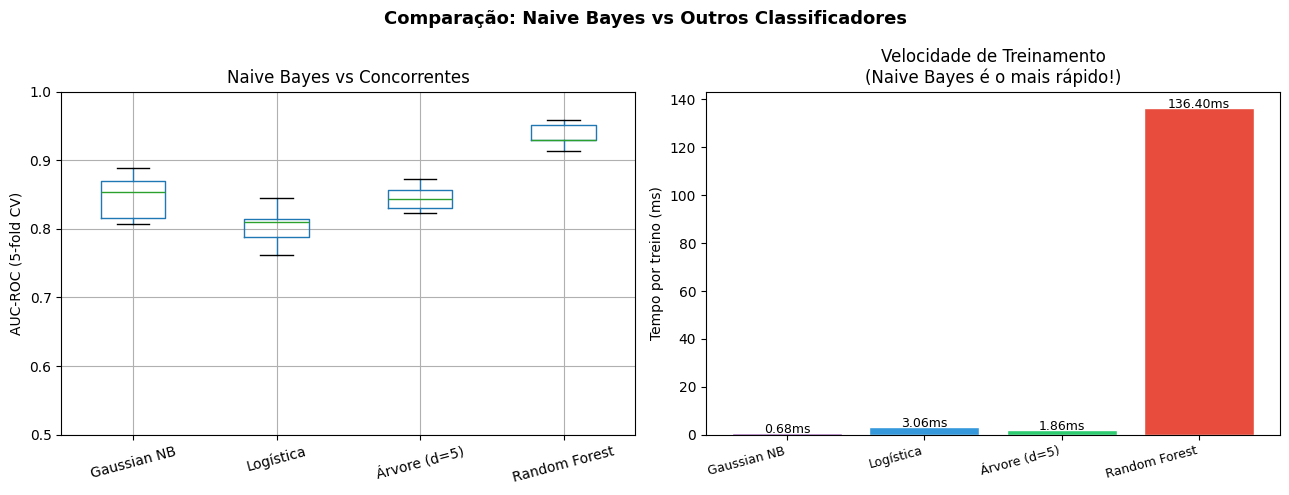

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

print("=" * 55)
print("📧 MULTINOMIAL NAIVE BAYES — CLASSIFICAÇÃO DE TEXTO (SPAM)")
print("=" * 55)

# Dataset de spam/ham sintético em português
emails_ham = [
    "Reunião amanhã às 10h na sala de conferências com o cliente",
    "Segue o relatório mensal de vendas conforme solicitado",
    "Por favor confirme o recebimento deste documento",
    "Precisamos conversar sobre o projeto antes da entrega",
    "O prazo para entrega do relatório é sexta-feira",
    "Estou enviando os dados para sua análise",
    "Reunião adiada para semana que vem conforme combinado",
    "Pode me enviar o contato do fornecedor quando possível",
    "Obrigado pela apresentação de hoje ficou muito boa",
    "Segue em anexo a proposta comercial revisada",
]
emails_spam = [
    "PROMOÇÃO IMPERDÍVEL ganhe R$1000 grátis clicando aqui agora",
    "Você foi selecionado para receber um prêmio especial urgente",
    "Oferta exclusiva por tempo limitado compre já com desconto",
    "Clique aqui para resgatar seu prêmio antes que expire",
    "Ganhe dinheiro fácil trabalhando em casa renda extra garantida",
    "Promoção especial hoje apenas desconto de 90 porcento",
    "Você ganhou um smartphone grátis retire já seu presente",
    "Oferta imperdível apenas hoje 100 reais de crédito grátis",
    "Urgente confirme seus dados para receber seu benefício",
    "Dinheiro extra garantido apenas cadastre seus dados agora",
]

textos = emails_ham + emails_spam
rotulos = [0]*10 + [1]*10

from sklearn.model_selection import StratifiedKFold
cv_mnb = cross_val_score(
    Pipeline([('tfidf', TfidfVectorizer()), ('mnb', MultinomialNB())]),
    textos, rotulos, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='accuracy'
)
print(f"Multinomial NB — Acurácia CV: {cv_mnb.mean():.3f} ± {cv_mnb.std():.3f}")

# Comparação dos modelos de NB no dataset de crédito
comparacao_nb = {}
for nome, modelo in [
    ('Gaussian NB', GaussianNB()),
    ('Bernoulli NB', BernoulliNB()),
]:
    pipe = Pipeline([('sc', StandardScaler()), ('nb', modelo)])
    scores = cross_val_score(pipe, X_cred, y_cred, cv=5, scoring='roc_auc')
    comparacao_nb[nome] = scores

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparação: Naive Bayes vs Outros Classificadores', fontsize=13, fontweight='bold')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

todos_modelos = {
    'Gaussian NB': GaussianNB(),
    'Logística': Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(random_state=42))]),
    'Árvore (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}
cv_results = {}
for nome, modelo in todos_modelos.items():
    scores = cross_val_score(modelo, X_cred, y_cred, cv=5, scoring='roc_auc')
    cv_results[nome] = scores

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=axes[0], rot=15)
axes[0].set_ylabel('AUC-ROC (5-fold CV)'); axes[0].set_title('Naive Bayes vs Concorrentes')
axes[0].set_ylim(0.5, 1.0)

# Velocidade de treinamento
import time
tempos = {}
for nome, modelo in todos_modelos.items():
    t0 = time.time()
    for _ in range(100):
        modelo.fit(X_tr, y_tr)
    tempos[nome] = (time.time() - t0) / 100 * 1000  # ms

axes[1].bar(tempos.keys(), tempos.values(), color=['#9b59b6','#3498db','#2ecc71','#e74c3c'], 
             edgecolor='white')
axes[1].set_ylabel('Tempo por treino (ms)'); axes[1].set_title('Velocidade de Treinamento\n(Naive Bayes é o mais rápido!)')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right', fontsize=9)
for i, (nome, v) in enumerate(tempos.items()):
    axes[1].text(i, v+0.05, f'{v:.2f}ms', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../imagens/12_nb_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Resumo e Exercícios

### Quando Usar Naive Bayes?

| Situação | Recomendação |
|----------|--------------|
| Classificação de texto (spam, sentimento) | ✅ Multinomial NB ou Complement NB |
| Features binárias (presença/ausência) | ✅ Bernoulli NB |
| Features contínuas com distribuição aproximadamente normal | ✅ Gaussian NB |
| Dataset muito pequeno | ✅ NB é robusto (menos parâmetros) |
| Dataset muito grande e velocidade importa | ✅ NB treina em O(n) |
| Features altamente correlacionadas | ❌ Viola suposição de independência |
| Precisão máxima importa mais que velocidade | ❌ Prefira ensemble methods |

### Vantagens do Naive Bayes
- **Velocidade**: treino e inferência extremamente rápidos
- **Poucos dados**: funciona bem com datasets pequenos
- **Interpretabilidade**: as probabilidades têm significado direto
- **Atualização incremental**: pode ser treinado online (observação por observação)
- **Baseline sólido**: frequentemente supera modelos mais complexos em texto

### Limitações
- **Suposição de independência**: raramente verdadeira na prática
- **Zero-frequency**: features ausentes no treino causam probabilidade zero (use smoothing)
- **Calibração**: as probabilidades podem não ser bem calibradas

---

### Exercícios

1. **Exercício 1 — Bayes Manual**: Uma empresa quer detectar fraudes. A taxa de fraude é 0.5%. O sistema de detecção tem sensibilidade 92% e especificidade 97%. Calcule P(fraude|alerta).

2. **Exercício 2 — Gaussian NB**: Use o dataset `wine` do sklearn. Treine um GaussianNB e compare com Logistic Regression. Plote as distribuições P(xᵢ|C) para as 3 features mais discriminativas.

3. **Exercício 3 — Multinomial NB para Texto**: Colete 20 tweets sobre 2 tópicos diferentes. Treine um MultinomialNB com TF-IDF. Quais palavras mais contribuem para cada classe?

4. **Desafio**: Implemente o Gaussian Naive Bayes do zero em Python (sem sklearn). Valide que os resultados coincidem com o GaussianNB do sklearn.